# Naive Bayes Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\nayer\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\nayer\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [7]:
X = df.drop('target', axis=1)

In [8]:
y = df['target']

In [9]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=101
)

In [12]:
X_train.shape

(272, 13)

In [13]:
X_test.shape

(31, 13)

In [14]:
y_train.shape

(272,)

In [15]:
y_test.shape

(31,)

In [16]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
13,64,1,3,110,211,0,0,144,1,1.8,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
171,48,1,1,110,229,0,1,168,0,1.0,0,0,3
128,52,0,2,136,196,0,0,169,0,0.1,1,0,2
119,46,0,0,138,243,0,0,152,1,0.0,1,0,2


In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)

In [20]:
X_test_scaled = scaler.transform(X_test)

In [21]:
X_train_scaled

array([[ 1.04970247,  0.69737995,  1.97993226, ..., -0.67167968,
        -0.71422572, -0.4842146 ],
       [ 0.61644136,  0.69737995, -0.94692412, ...,  0.9451068 ,
         1.23823052,  1.14178999],
       [-0.68334197,  0.69737995,  0.02869467, ..., -2.28846615,
        -0.71422572,  1.14178999],
       ...,
       [-0.89997253,  0.69737995,  0.02869467, ...,  0.9451068 ,
        -0.71422572,  1.14178999],
       [-1.44154891,  0.69737995,  0.02869467, ..., -0.67167968,
        -0.71422572, -2.11021919],
       [-0.68334197, -1.43393855,  1.00431346, ...,  0.9451068 ,
        -0.71422572, -0.4842146 ]])

In [22]:
X_test_scaled

array([[ 0.07486497,  0.69737995, -0.94692412,  0.47001573, -0.55502259,
        -0.42732739,  0.89828426, -1.70935702,  1.47064295,  4.11840557,
        -2.28846615, -0.71422572,  1.14178999],
       [-0.25008086,  0.69737995,  1.00431346,  2.28905391, -0.89683273,
         2.34012617,  0.89828426,  0.52722104, -0.6799747 , -0.43237682,
         0.9451068 , -0.71422572,  1.14178999],
       [ 0.3998108 , -1.43393855, -0.94692412, -1.803782  ,  0.03365043,
        -0.42732739, -0.99577247, -1.22695783, -0.6799747 ,  0.01377832,
        -0.67167968, -0.71422572, -0.4842146 ],
       [-1.65817947, -1.43393855,  1.00431346,  0.35632584, -0.49805423,
        -0.42732739,  0.89828426,  0.08867632, -0.6799747 , -0.87853195,
        -0.67167968, -0.71422572, -0.4842146 ],
       [ 0.61644136,  0.69737995, -0.94692412, -0.38265842,  0.22354495,
        -0.42732739, -0.99577247, -0.39372287,  1.47064295,  1.61993681,
        -0.67167968,  0.2620024 ,  1.14178999],
       [-0.57502669,  0.697379

**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage.**

## Naive Bayes Model

**TASK: Create Naive Bayes model

In [23]:
from sklearn.naive_bayes import GaussianNB

In [24]:
nb_model = GaussianNB()

In [25]:
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [26]:
y_pred = nb_model.predict(X_test_scaled)

In [27]:
y_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0], dtype=int64)

In [28]:
y_test.values

array([0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0], dtype=int64)

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [29]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [30]:
confusion_matrix(y_test, y_pred)

array([[13,  2],
       [ 2, 14]], dtype=int64)

In [31]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[13,  2],
       [ 2, 14]], dtype=int64)

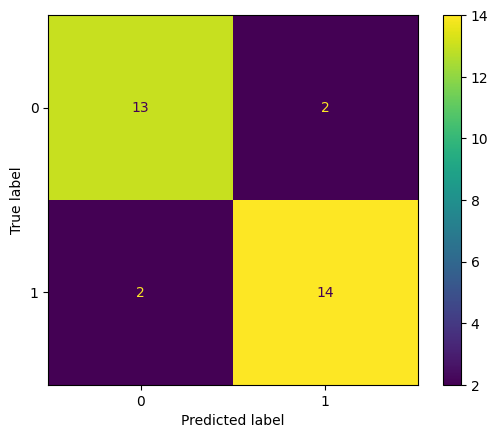

In [32]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.88      0.88      0.88        16

    accuracy                           0.87        31
   macro avg       0.87      0.87      0.87        31
weighted avg       0.87      0.87      0.87        31



**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [34]:
patient = [[48.0, 0.0, 2.0, 130.0, 275.0, 0.0, 1.0, 139.0, 0.0, 0.2, 2.0, 0.0, 2.0]]

In [35]:
patient_scaled = scaler.transform(patient)

c:\Users\nayer\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [36]:
nb_model.predict(patient_scaled)

array([1], dtype=int64)

In [37]:
nb_model.predict_proba(patient_scaled)

array([[0.00113704, 0.99886296]])

In [38]:
prediction = nb_model.predict(patient_scaled)[0]
probabilities = nb_model.predict_proba(patient_scaled)[0]

print("Predicted class:", prediction)
print("Probability for class 0 (no heart disease):", probabilities[0])
print("Probability for class 1 (heart disease):", probabilities[1])

Predicted class: 1
Probability for class 0 (no heart disease): 0.001137036049645272
Probability for class 1 (heart disease): 0.9988629639503556
